In [1]:
%matplotlib inline

from matplotlib import pyplot
import numpy, scipy, pandas

pyplot.rc('figure', figsize=[12, 8], dpi=144)
pyplot.rc('text', usetex=True)

In [2]:
def generate_direction_vectors(n, phi_min=0, phi_max=2 * numpy.pi, theta_min=0, theta_max=numpy.pi,
                                phi_distribution=numpy.random.uniform, theta_distribution=numpy.random.uniform):
    phi = phi_distribution(phi_min, phi_max, (n,))
    theta = theta_distribution(theta_min, theta_max, (n,))
    sin_theta = numpy.sin(theta)
    return numpy.dstack((numpy.cos(phi) * sin_theta, numpy.sin(phi) * sin_theta, numpy.cos(theta)))[0]
    
generate_direction_vectors(10)

array([[ 0.77922808, -0.58397248, -0.22755162],
       [ 0.51018272,  0.13423532, -0.84952603],
       [-0.11232813, -0.98371936,  0.14028048],
       [-0.33514168, -0.42012699,  0.84331096],
       [-0.306483  , -0.77848624, -0.54774752],
       [-0.37556115, -0.07686204,  0.92360492],
       [-0.85545244,  0.24002833,  0.45889817],
       [-0.68328008, -0.38449447,  0.6207192 ],
       [ 0.07227862, -0.6147772 , -0.78538194],
       [-0.9048141 ,  0.30780968,  0.2942187 ]])

In [3]:
def simulate(n_photons=10, optical_depth=0.1, albedo=0.7, n_steps=1000):
    # Light source at (1, 0, 0) on the ground and pointed into the room
    position_vectors = numpy.zeros((n_steps + 1, n_photons, 3), dtype=numpy.float32)
    position_vectors[0, :, 0] = 1
    direction_vectors = generate_direction_vectors(n_photons, phi_min=numpy.pi/2, phi_max=numpy.pi, theta_min=0, theta_max=numpy.pi/2)
    intensities = numpy.zeros((n_steps + 1, n_photons), dtype=numpy.float32)
    intensities[0, :] = 1
    reflector = numpy.ones((3, 3))
    bias = 2 * numpy.eye(3)
    reflector -= bias
    for i in range(1, n_steps + 1):
        position_vectors[i] = position_vectors[i - 1] + optical_depth * direction_vectors
        intensities[i] = 1 * intensities[i - 1]
        for axis in range(3):
            # Reflections off surface at xi = 0
            reflected_photons = position_vectors[i, :, axis] <= 0
            #position_vectors[i][reflected_photons] *= reflector[axis]
            direction_vectors[reflected_photons] *= reflector[axis]
            intensities[i][reflected_photons] = albedo * intensities[i - 1][reflected_photons]
        for axis in range(1, 3):
            # Reflections off surface at xi = 1
            reflected_photons = position_vectors[i, :, axis] >= 1
            #position_vectors[i][reflected_photons] *= reflector[axis]
            #position_vectors[i][reflected_photons] += bias[axis]
            direction_vectors[reflected_photons] *= reflector[axis]
            intensities[i][reflected_photons] = albedo * intensities[i - 1][reflected_photons]
    return position_vectors, intensities


In [4]:
paths, intensities = simulate(n_photons=1000000, optical_depth=0.1, n_steps=100, albedo=0.9)
#paths[:,0,:], intensities[:, 0]

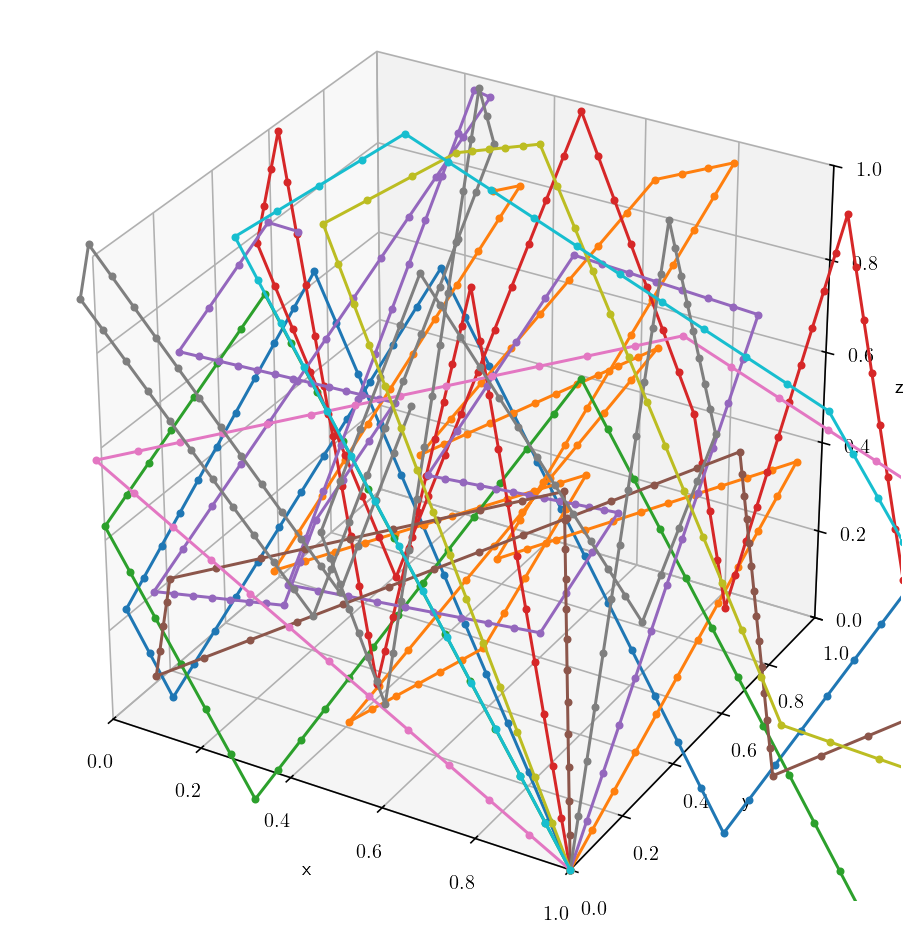

In [5]:
figure = pyplot.figure()
axes = figure.add_subplot(projection='3d')
axes.set_aspect('equal')
axes.set(xlim3d=(0, 1))
axes.set(ylim3d=(0, 1))
axes.set(zlim3d=(0, 1))
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_zlabel('z')

for i in range(10):
    axes.plot3D(paths[:, i, 0], paths[:, i, 1], paths[:, i, 2], marker='.')

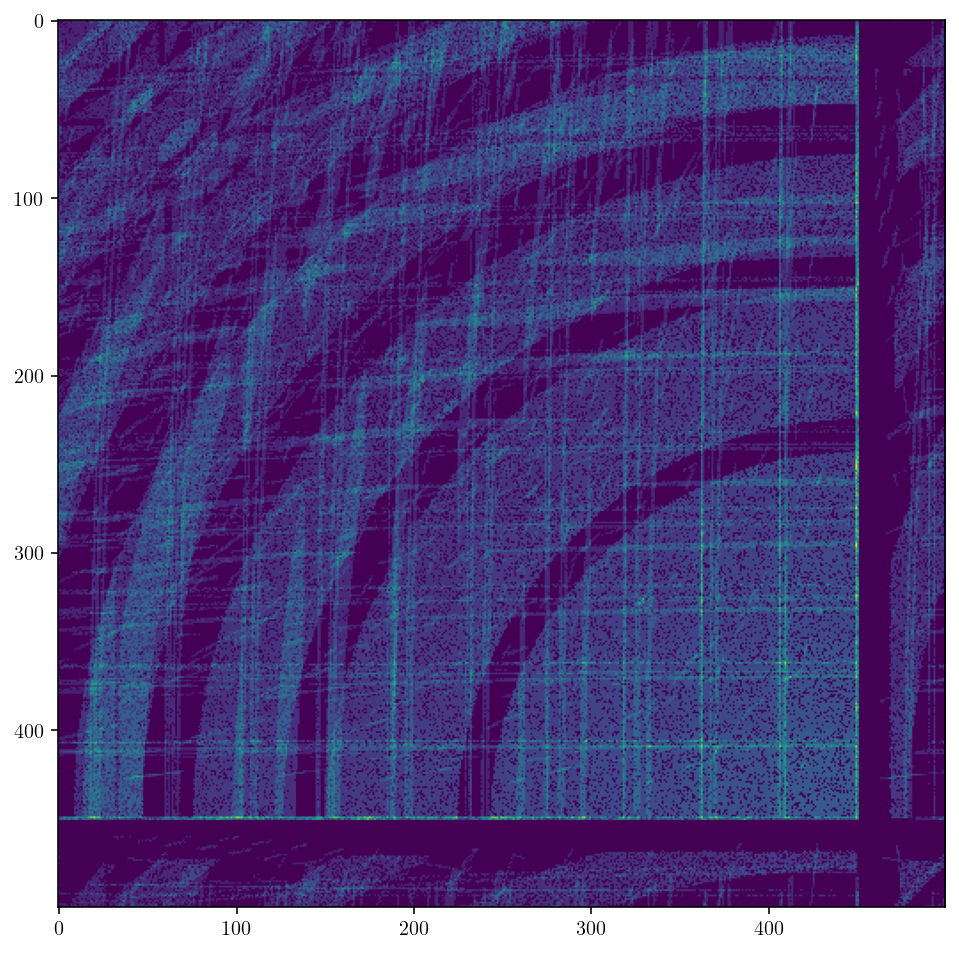

In [6]:
escaped_photons = (paths[-1][:, 0] >= 1.) & (intensities[-1] > 0.)

image = numpy.zeros((500, 500), dtype=numpy.float32)

for i in range(100, 0, -1):
    reflections = escaped_photons & (paths[i][:, 0] <= 0)
    if reflections.any():
        image[((1 - paths[i][reflections][:, 1]) * 450).astype(numpy.int64), ((1 - paths[i][reflections][:, 2]) * 450).astype(numpy.int64)] += intensities[-1][reflections]

pyplot.imshow(image / image.max())